In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
base  = sns.load_dataset("diamonds")
base.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
base.shape

(53940, 10)

In [7]:
base.dropna(inplace=True)

In [8]:
base.shape

(53940, 10)

In [9]:
media_poblacional = base['price'].mean()
varianza_poblacional = base['price'].var()
print(media_poblacional, varianza_poblacional)

3932.799721913237 15915629.42430145


## Punto 1

In [14]:
muestra = base['price'].sample(n=30, replace=True)
media_muestral = muestra.mean()
varianza_muestral = np.var(muestra, ddof=1)
print(f'la muestra es')
display(muestra)
print(f'su media muestral es {media_muestral}')
print(f'su varianza muestral es {varianza_muestral}')


la muestra es


36888      959
36         402
41143     1197
31555      766
53509     2686
21007     9218
2794      3259
6991      4155
46589     1786
2182      3136
25886    15005
29041      687
19158     7917
10655     4838
30425      730
4679      3673
43107     1385
32838      807
27750      648
41643     1238
14190     5758
46754     1800
46511     1779
15486     6203
23661    11709
50833     2310
44120     1559
27964      658
1292      2952
24116    12271
Name: price, dtype: int64

su media muestral es 3716.366666666667
su varianza muestral es 14990913.619540233


In [17]:
print(f'La media poblacional es {media_poblacional}, mientras que su media muestral es {media_muestral}')
print(f'La varianza poblacional es {varianza_poblacional}, mientras que su varianza muestral es {varianza_muestral}')


La media poblacional es 3932.799721913237, mientras que su media muestral es 3716.366666666667
La varianza poblacional es 15915629.42430145, mientras que su varianza muestral es 14990913.619540233


Tanto la media como la varianza muestral no serán iguales ni hay que esperar que sean iguales a los valores pobalcionales, debido a que sólo estamos viendo a un parte pequeña de la población, y para saber la información verdadera debemos estudiar a toda, y es justo lo que no hacemos al tomar una meustra.

In [27]:
muestra_10 = base['price'].sample(n=10, replace=True)
media_muestral_10 = muestra_10.mean()
varianza_muestral_10 = np.var(muestra_10, ddof=1)

muestra_100 = base['price'].sample(n=100, replace=True)
media_muestral_100 = muestra_100.mean()
varianza_muestral_100 = np.var(muestra_100, ddof=1)

In [28]:
print(f'La media muestral con 10 muestras es {media_muestral_10}, la media muestral con 30 muestras es {media_muestral}, la media muestral con 100 muestras es {media_muestral_100}')

La media muestral con 10 muestras es 3953.3, la media muestral con 30 muestras es 3716.366666666667, la media muestral con 100 muestras es 3989.21


Observo que mientras más grande es la muestra más cercano puede ser al valor real, sin embargo, para este ejemplo para n=10 salio más grande

## Parte 2

In [ ]:
n=30
B=5000

mu_1=[]
mu_2=[]
mu_3=[]

for _ in range(B):
    muestra = base['price'].sample(n=n, replace=True)
    mu_est_1 = muestra.mean()
    mu_est_2 = muestra.mean()*0.9
    mu_est_3 = muestra.mean()*1.1

    mu_1.append(mu_est_1)
    mu_2.append(mu_est_2)
    mu_3.append(mu_est_3)

mu_1 = np.array(mu_1)
mu_2 = np.array(mu_2)
mu_3 = np.array(mu_3)

media_mu_1 = mu_1.mean()
media_mu_2 = mu_2.mean()
media_mu_3 = mu_3.mean()

print(f'la media poblacional es {media_poblacional}')
print(f'la media del estimador mu 1 es {media_mu_1}')
print(f'la media del estimador mu 2 es {media_mu_2}')
print(f'la media del estimador mu 3 es {media_mu_3}')

la media poblacional es 3932.799721913237
la media del estimador mu 1 es 3949.730733333333
la media del estimador mu 2 es 3554.7576599999993
la media del estimador mu 3 es 4344.703806666666


Vemos que el estimador $\mu_1$ está más cercano al valor verdadero porque sólo difiere por un valor de alrededor de 17, ya que $\mu_2$ está muy por debajo y $\mu_3$ está muy por arriba de la media poblacional. Y esto se nota debido a que respectivamente se multiplico por 0.9 y 1.1

La estimación es el valor que obtenemos al aplicar el estimador sobre la muestra, es decir, el estimador es la operación matemática que debemos de hacer sobre las muestra para obtener un valor o tener una idea del comportamiento de la muestra y dicho valor en concreto es la estimación


## Punto 3

In [30]:
sesgo_1 = media_mu_1 - media_poblacional
sesgo_2 = media_mu_2 - media_poblacional
sesgo_3 = media_mu_3 - media_poblacional

print(f'el sesgo de mu_1 es {sesgo_1}')
print(f'el sesgo de mu_2 es {sesgo_2}')
print(f'el sesgo de mu_3 es {sesgo_3}')



el sesgo de mu_1 es 16.93101142009573
el sesgo de mu_2 es -378.04206191323783
el sesgo de mu_3 es 411.9040847534293


Parece que el valor insesgado podría ser la $\mu_1$, ya que verificamos que su diferencia es minima es decir 16, muy parecido.

Sabemos que $E[\bar{X}] = \mu$ pero $\bar{X}$ es el estimador $\mu_1$ por lo tanto el valor esperado de $\hat{\mu}_1=\mu$ de está manera $Sesgo(\hat{\mu}_1) = E[\bar{X}]-\mu=\mu-\mu=0$ 

In [33]:
n=30
B=5000

mu_1=[]
mu_2=[]
mu_3=[]

var_1 = []
var_2 = []

for _ in range(B):
    muestra = base['price'].sample(n=n, replace=True)
    mu_est_1 = muestra.mean()
    mu_est_2 = muestra.mean()*0.9
    mu_est_3 = muestra.mean()*1.1

    var_est_1 = np.var(muestra, ddof=0)
    var_est_2 = np.var(muestra, ddof=1)

    mu_1.append(mu_est_1)
    mu_2.append(mu_est_2)
    mu_3.append(mu_est_3)

    var_1.append(var_est_1)
    var_2.append(var_est_2)


mu_1 = np.array(mu_1)
mu_2 = np.array(mu_2)
mu_3 = np.array(mu_3)

var_1 = np.array(var_1)
var_2 = np.array(var_2)

media_mu_1 = mu_1.mean()
media_mu_2 = mu_2.mean()
media_mu_3 = mu_3.mean()

ve_var_1 = var_1.mean()
ve_var_2 = var_2.mean()

print(f'la varianza poblacional es {varianza_poblacional}')
print(f'el valor esperado de var_1 es {ve_var_1}')
print(f'la valor esperado de var_2 es {ve_var_2}')


la varianza poblacional es 15915629.42430145
el valor esperado de var_1 es 15300772.794337556
la valor esperado de var_2 es 15828385.649314713


La razón para calcular la varianza con ddof=1 debido a que estamos usando muestras, y para evitar un sesgo en nuestra muestra usamos (n-1) en la varianza o en python es con ddof=1, además para conocer la suma de todas las desviaciones debe ser igual a 0, por lo que si se conoce las desviaciones de n-1 por lo tanto la desviación n debe de ser 0 para no afectar la suma.

Además podemos ver claramente que la varianza insesgada es decir con ddof = 1 es la más cercana a la varianza poblacional, y que la varianza con ddof = 0 está más alejada.

## Punto 4

In [45]:
ecm_1 = np.mean((mu_1-media_poblacional)**2)
ecm_2 = np.mean((mu_2-media_poblacional)**2)
ecm_3 = np.mean((mu_3-media_poblacional)**2)

print(f'el error cuadrático medio de mu_1 es {ecm_1}')
print(f'el error cuadrático medio de mu_2 es {ecm_2}')
print(f'el error cuadrático medio de mu_3 es {ecm_3}')


el error cuadrático medio de mu_1 es 535634.9546207829
el error cuadrático medio de mu_2 es 597928.813699368
el error cuadrático medio de mu_3 es 791304.2090371802


Notamos que el que tiene menor ECM es el estimador de $\mu_1$

In [58]:
varianza_mu_1 = np.var(mu_1, ddof=0)
varianza_mu_2 = np.var(mu_2, ddof=0)
varianza_mu_3 = np.var(mu_3, ddof=0)

print(f'la varianza de mu_1 es {varianza_mu_1}')
print(f'la varianza de mu_2 es {varianza_mu_2}')
print(f'la varianza de mu_3 es {varianza_mu_3}')


la varianza de mu_1 es 535458.80628551
la varianza de mu_2 es 433721.6330912631
la varianza de mu_3 es 647905.1556054673


In [59]:
sesgo_1 = media_mu_1 - media_poblacional
sesgo_2 = media_mu_2 - media_poblacional
sesgo_3 = media_mu_3 - media_poblacional

aprox_ecm_1 = varianza_mu_1 + (sesgo_1)**2
aprox_ecm_2 = varianza_mu_2 + (sesgo_2)**2
aprox_ecm_3 = varianza_mu_3 + (sesgo_3)**2

print(f'el ecm aproximado de mu_1 es {aprox_ecm_1}')
print(f'el ecm aproximado de mu_2 es {aprox_ecm_2}')
print(f'el ecm aproximado de mu_3 es {aprox_ecm_3}')



el ecm aproximado de mu_1 es 535634.9546207828
el ecm aproximado de mu_2 es 597928.8136993678
el ecm aproximado de mu_3 es 791304.2090371801


In [60]:
print(f'el ecm es {ecm_1} el valor aproximado es {aprox_ecm_1}')
print(f'el ecm es {ecm_2} el valor aproximado es {aprox_ecm_2}')
print(f'el ecm es {ecm_3} el valor aproximado es {aprox_ecm_3}')


el ecm es 535634.9546207829 el valor aproximado es 535634.9546207828
el ecm es 597928.813699368 el valor aproximado es 597928.8136993678
el ecm es 791304.2090371802 el valor aproximado es 791304.2090371801


Si un estimador insesgado necesariamente tienen menor ECM debido a que ECM = varianza + sesgo^2 y para los estimadores insesgados es sesgo = 0, por lo tanto no tiene una parte de la suma, lo que hace menor a una ECM con estimador sesgado.

## Parte 5

In [62]:
c = np.arange(0.8, 1.2 + 0.001, 0.01).round(2).tolist()
c

[0.8,
 0.81,
 0.82,
 0.83,
 0.84,
 0.85,
 0.86,
 0.87,
 0.88,
 0.89,
 0.9,
 0.91,
 0.92,
 0.93,
 0.94,
 0.95,
 0.96,
 0.97,
 0.98,
 0.99,
 1.0,
 1.01,
 1.02,
 1.03,
 1.04,
 1.05,
 1.06,
 1.07,
 1.08,
 1.09,
 1.1,
 1.11,
 1.12,
 1.13,
 1.14,
 1.15,
 1.16,
 1.17,
 1.18,
 1.19,
 1.2]

In [69]:
n = 30
B = 100
mus = []

for i in range(len(c)):
    aux = []
    for _ in range(B):
        muestra = base['price'].sample(n=n, replace=True)
        mu_est = muestra.mean()*c[i]
        aux.append(mu_est)
    mus.append(aux)

In [71]:
vector_sesgos = []
mus = np.array(mus)
for i in range(len(c)):
    media = mus[i].mean()
    vector_sesgos.append(media-media_poblacional)
vector_sesgos

[np.float64(-808.468788579904),
 np.float64(-677.9208319132367),
 np.float64(-613.9084885799043),
 np.float64(-746.4111852465699),
 np.float64(-562.9669619132378),
 np.float64(-611.3850552465706),
 np.float64(-556.0905619132373),
 np.float64(-468.45247191323733),
 np.float64(-516.8001752465702),
 np.float64(-447.37964524656945),
 np.float64(-402.075721913237),
 np.float64(-245.79670524657013),
 np.float64(-324.26808191323653),
 np.float64(-223.0256919132371),
 np.float64(-173.8061485799035),
 np.float64(-186.4671219132374),
 np.float64(-195.44708191323753),
 np.float64(-178.11628524657135),
 np.float64(97.85077142009595),
 np.float64(-35.17203191323688),
 np.float64(-13.229388579904025),
 np.float64(20.340614753430145),
 np.float64(108.67147808676236),
 np.float64(167.29621475343038),
 np.float64(167.4075580867625),
 np.float64(249.0317780867631),
 np.float64(306.0194380867638),
 np.float64(323.6659847534297),
 np.float64(401.908078086763),
 np.float64(366.6991014200962),
 np.float64(5

In [72]:
vector_varianzas = []

for i in range(len(c)):
    varianza = np.var(mus[i], ddof=1)
    vector_varianzas.append(varianza)
vector_varianzas

[np.float64(264712.0805077621),
 np.float64(344491.02827230096),
 np.float64(374585.1108958956),
 np.float64(268736.512164103),
 np.float64(360589.5476527497),
 np.float64(368065.06316576875),
 np.float64(406260.45731979894),
 np.float64(451116.7993708157),
 np.float64(391592.8242488967),
 np.float64(413024.8485162376),
 np.float64(358097.7858909091),
 np.float64(453670.98462148674),
 np.float64(509970.27935687033),
 np.float64(406141.5889382314),
 np.float64(467575.1776483907),
 np.float64(426990.9858100628),
 np.float64(465158.8532876671),
 np.float64(379552.3583601273),
 np.float64(596082.8980332536),
 np.float64(619653.3190816101),
 np.float64(462467.56951503915),
 np.float64(554143.3566771167),
 np.float64(583711.2763137779),
 np.float64(636560.0047127287),
 np.float64(467301.26507397246),
 np.float64(549939.9728118688),
 np.float64(478182.072575871),
 np.float64(806742.124025684),
 np.float64(573537.1830905454),
 np.float64(545795.4326444075),
 np.float64(472849.3715052964),
 np.

In [74]:
vector_varianzas = np.array(vector_varianzas)
vector_sesgos = np.array(vector_sesgos) 
vector_ecm = vector_varianzas + vector_sesgos**2
vector_ecm

array([ 918333.86261562,  804067.68261424,  751468.74324636,
        825866.16962529,  677521.34785857,  741856.74894462,
        715497.17036878,  670564.51781244,  658675.24538378,
        613173.39549718,  519762.67204296,  514087.00493156,
        615120.06830456,  455882.04819161,  497783.75493257,
        461760.97336467,  503358.41511607,  411277.76943017,
        605657.67150076,  620890.39091052,  462642.58623724,
        554557.09728566,  595520.76646334,  664548.02818355,
        495326.55557855,  611956.79930892,  571829.96906281,
        911501.79371209,  735067.28632194,  680263.66362671,
        777597.50891133,  613148.44577974,  822967.0971057 ,
        673919.73606517, 1038259.75931029, 1009657.71340095,
       1225761.2514253 , 1086857.1057398 , 1412347.06885313,
       1329281.39994915, 1370208.9307725 ])

Text(0, 0.5, 'ECM')

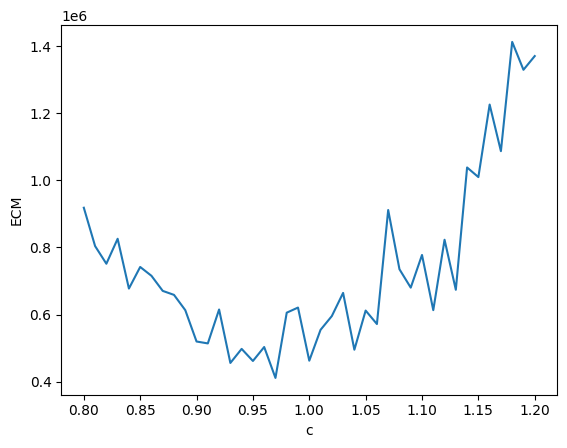

In [76]:
plt.plot(c, vector_ecm)
plt.xlabel('c')
plt.ylabel('ECM')

In [77]:
indice_minimo_ecm = np.argmin(vector_ecm) 
valor_minimo_c = c[indice_minimo_ecm]
valor_minimo_c

0.97

In [78]:
print(media_mu_1)
print(min(vector_ecm))

3919.5276333333327
411277.7694301653
